In [27]:
import pandas as pd

url = "https://raw.githubusercontent.com/nkmwicz/data-for-students/refs/heads/main/airbnb_data.csv"
df = pd.read_csv(url)
df.head()

/var/folders/yr/rc7j6wgn1v7gg0h_hdxxl9r00000gn/T/ipykernel_16096/1673983165.py:4: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url)


,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [28]:
df["price"]

0           $966 
1           $142 
2           $620 
3           $368 
4           $204 
           ...   
102594      $844 
102595      $837 
102596      $988 
102597      $546 
102598    $1,032 
Name: price, Length: 102599, dtype: object

In [29]:
#I had to look up how to clean up the price column becuase using past code that we had done wasnt working
#thats why theres some differnet stuff like regex.

df['price'] = df['price'].astype(str).str.replace(r'[\$,]', '', regex=True)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

df['price']

0          966.0
1          142.0
2          620.0
3          368.0
4          204.0
           ...  
102594     844.0
102595     837.0
102596     988.0
102597     546.0
102598    1032.0
Name: price, Length: 102599, dtype: float64

In [30]:
df["reviews per month"]

0         0.21
1         0.38
2          NaN
3         4.64
4         0.10
          ... 
102594     NaN
102595    0.02
102596     NaN
102597    0.10
102598     NaN
Name: reviews per month, Length: 102599, dtype: float64

In [31]:
df = df.dropna(subset=["price", "reviews per month"])

In [32]:
df["reviews per month"]

0         0.21
1         0.38
3         4.64
4         0.10
5         0.59
          ... 
102588    3.78
102591    0.35
102593    0.16
102595    0.02
102597    0.10
Name: reviews per month, Length: 86500, dtype: float64

In [33]:
import scipy.stats as stats
r,p = stats.pearsonr(df["price"], df["reviews per month"])
r2 = r**2

print(f"r = {r:.4f}")
print(f"p = {p:.4f}")
print(f"r2 = {r2:.4f}")

r = 0.0042
p = 0.2183
r2 = 0.0000


In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

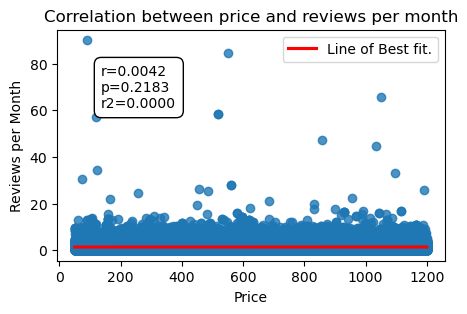

In [45]:
plt.figure(figsize=(5,3))
text = f"""r={r:.4f}
p={p:.4f}
r2={r2:.4f}""" 
reg = sns.regplot(
    data=df,
    x="price", 
    y= "reviews per month",
    line_kws={"color":"red","label": "Line of Best fit."})

reg.text(
    0.1,
    0.75,
    text,
    transform=scat.transAxes,
    bbox={"boxstyle":"round, pad=0.5", "fc": "white"})
reg.set(xlabel="Price", ylabel="Reviews per Month", title="Correlation between price and reviews per month")
plt.legend()

<Figure size 500x300 with 0 Axes>

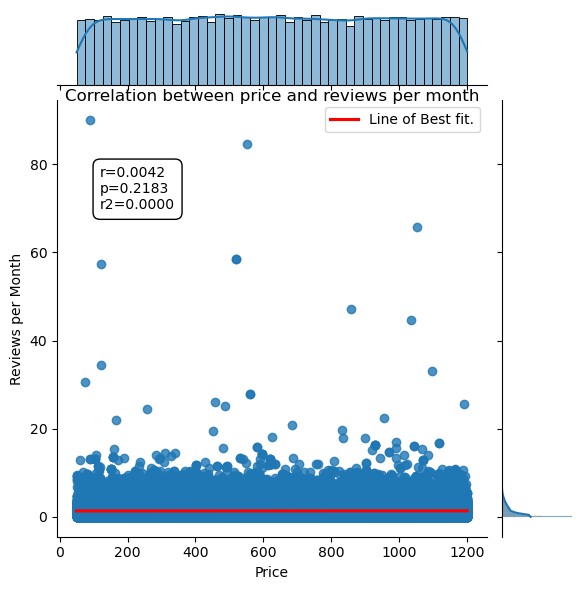

In [62]:
plt.figure(figsize=(5,3))
text = f"""r={r:.4f}
p={p:.4f}
r2={r2:.4f}""" 
joint = sns.jointplot(
    data=df,
    x="price",
    y="reviews per month",
    kind="reg",
    line_kws={"color":"red","label": "Line of Best fit."}
)

joint.ax_joint.text(
    0.1,
    0.75,
    text,
    transform=joint.ax_joint.transAxes,
    bbox={"boxstyle":"round, pad=0.5", "fc": "white"})
joint.set_axis_labels("Price", "Reviews per Month")
joint.ax_joint.set_title("Correlation between price and reviews per month",
    y=0.98)
plt.legend()
